# Traducción del IFU 3T (inglés → español) con fidelidad visual

Este notebook documenta **la metodología y los pasos** seguidos para traducir al
español el instructivo `3T-Quick-Start-for-cleaning-CP_IFU_16-XX-XX_Q_USA_001.pdf`
(Sistema Calentador-Enfriador 3T) **manteniendo la fidelidad** del contenido y de
la apariencia del original, y muestra **una página de cada PDF generado**, incluidos
los PDFs de control.


## Cómo se hizo la traducción

- La traducción del texto la realizó **Claude Code, a pedido por prompt**.
- Se **decidió NO usar llamadas a una API** de traducción porque la cantidad de
  texto es pequeña (un puñado de páginas); resultó más simple y reproducible
  incrustar las traducciones directamente en el script.
- El resultado se volcó en un diccionario `TRANSLATIONS` dentro de
  `scripts/04_translate_and_build.py`, que mapea el **texto exacto de cada span**
  (incluidos tabuladores y espacios) a su versión en español.
- Los números de paso, códigos y números de parte (`2.1`, `CP_IFU_16-XX-XX...`,
  `75-510-218`) se conservan **literales**.

## Principio rector de fidelidad

> **No se rehace el documento: se reemplaza únicamente la capa de texto, dejando
> intacto todo lo demás (fondo, imágenes, vectores, diagramas, flechas).**

## Pipeline

| Paso | Script | Salida principal |
|---|---|---|
| 1. Extracción fiel (texto + imágenes + fondo sin texto) | `01_extract.py` | `background_only.pdf`, `extracted_preview.pdf`, `extracted_text.json` |
| 2. Volcado de texto legible | `02_text_dump.py` | `extracted_text.txt` |
| 3. Control de la extracción (3 columnas) | `03_compare.py` | `comparacion_3col.pdf` |
| 4. Traducción (Claude Code) + armado | `04_translate_and_build.py` | `translated.pdf` |
| 5. Control de la traducción (3 columnas) | `05_compare_translated.py` | `comparacion_traducido.pdf` |

Mecanismos de fidelidad aplicados al reescribir el texto: misma posición (`origin`),
mismo color/tamaño, negrita/cursiva y versalitas, rotación de la línea, y
**auto-reducción del tamaño** si el español no entra, limitada por el siguiente
span u obstáculos (flechas) para no pisar figuras ni celdas vecinas.


In [1]:
import fitz  # PyMuPDF
from pathlib import Path
from IPython.display import Image, display, Markdown

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT = ROOT / 'output'
ORIG = ROOT / '3T-Quick-Start-for-cleaning-CP_IFU_16-XX-XX_Q_USA_001.pdf'

def mostrar_pagina(pdf_path, page_index=0, dpi=110, titulo=None):
    """Renderiza una página de un PDF a PNG y la muestra incrustada."""
    pdf_path = Path(pdf_path)
    if titulo:
        display(Markdown(f'### {titulo}'))
    display(Markdown(f'`{pdf_path.name}` — página {page_index + 1}'))
    doc = fitz.open(pdf_path)
    pix = doc[page_index].get_pixmap(dpi=dpi)
    png = pix.tobytes('png')
    doc.close()
    display(Image(data=png))


## 0) Original (inglés)
Punto de partida: el PDF tal cual fue recibido.

### Original

`3T-Quick-Start-for-cleaning-CP_IFU_16-XX-XX_Q_USA_001.pdf` — página 1

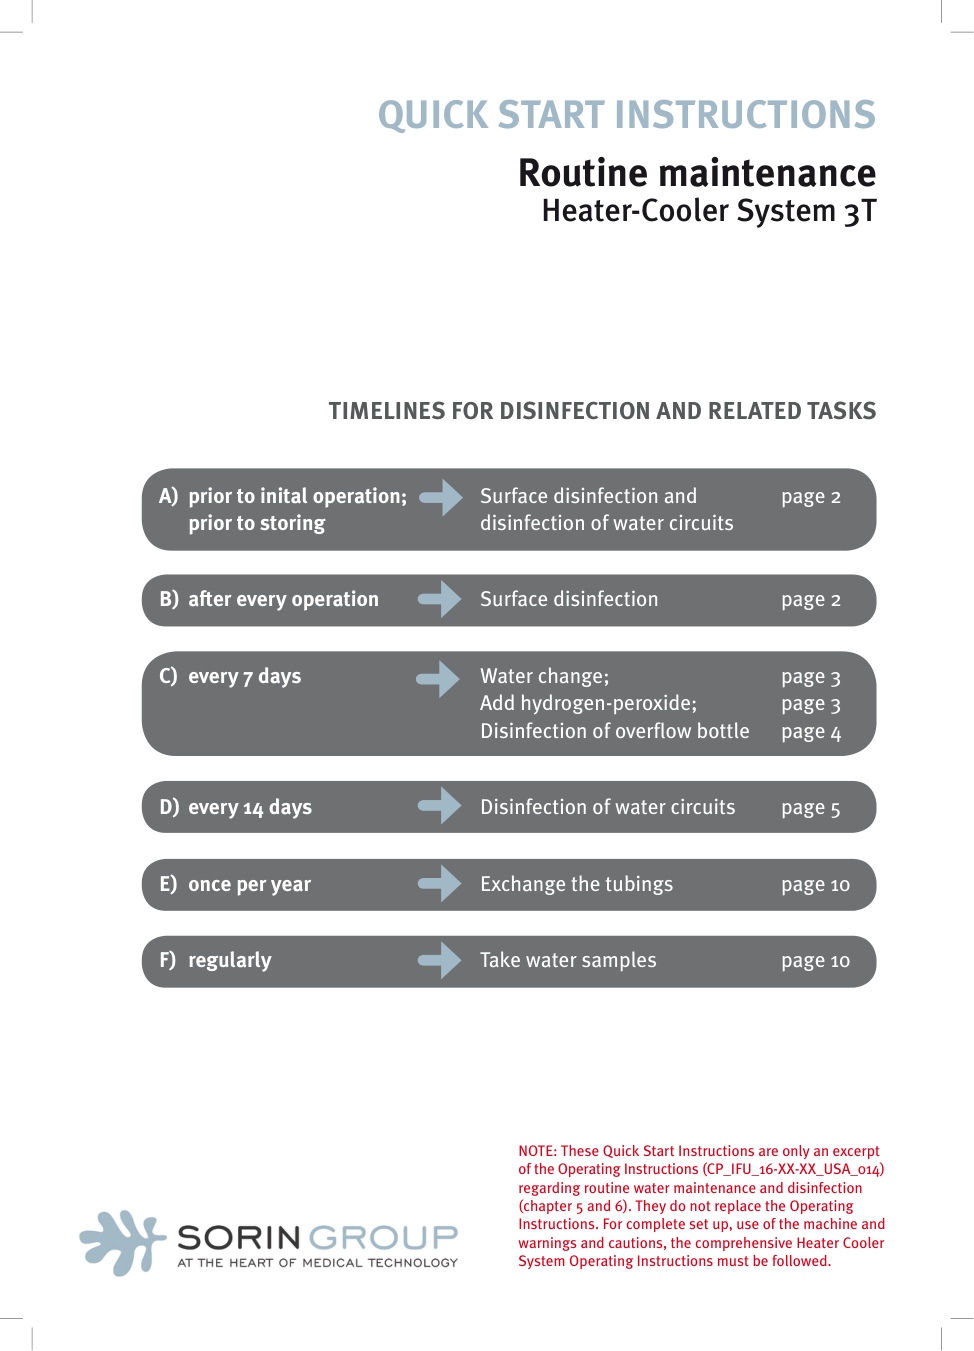

In [2]:
mostrar_pagina(ORIG, 0, titulo='Original')

## 1) `background_only.pdf` — fondo sin texto
Se eliminó **solo el texto** por redacción; imágenes, vectores y flechas quedan
intactos. Es el lienzo sobre el que se escribe el español.

### Fondo sin texto

`background_only.pdf` — página 1

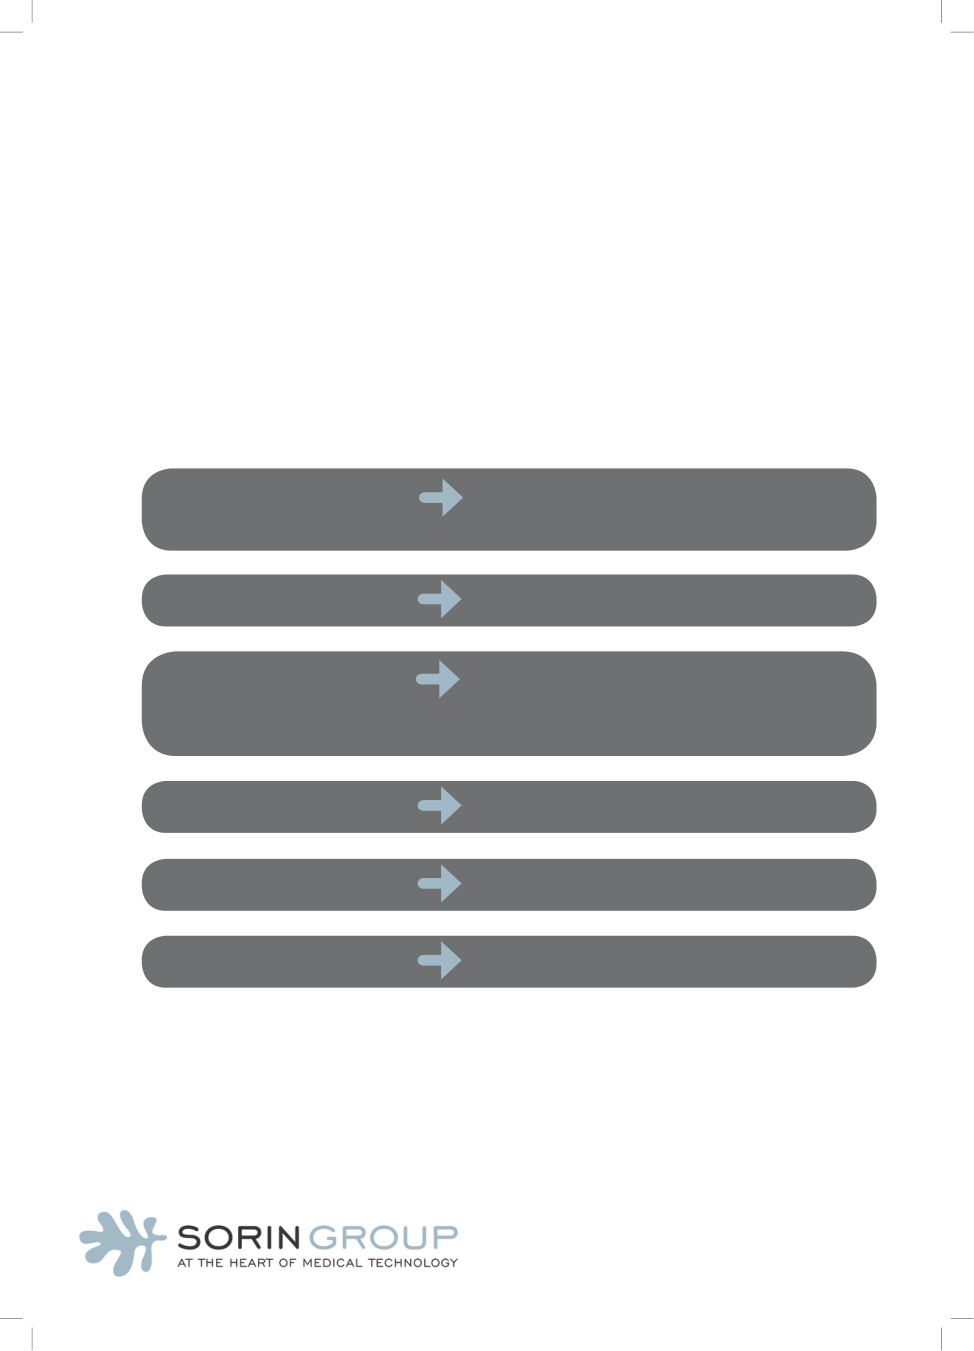

In [3]:
mostrar_pagina(OUT / 'background_only.pdf', 0, titulo='Fondo sin texto')

## 2) `extracted_preview.pdf` — reconstrucción de control
Vectores + imágenes + texto extraído recolocados sobre páginas en blanco, para
verificar que la extracción capturó todo en su lugar **(PDF de control)**.

### Reconstrucción (control)

`extracted_preview.pdf` — página 1

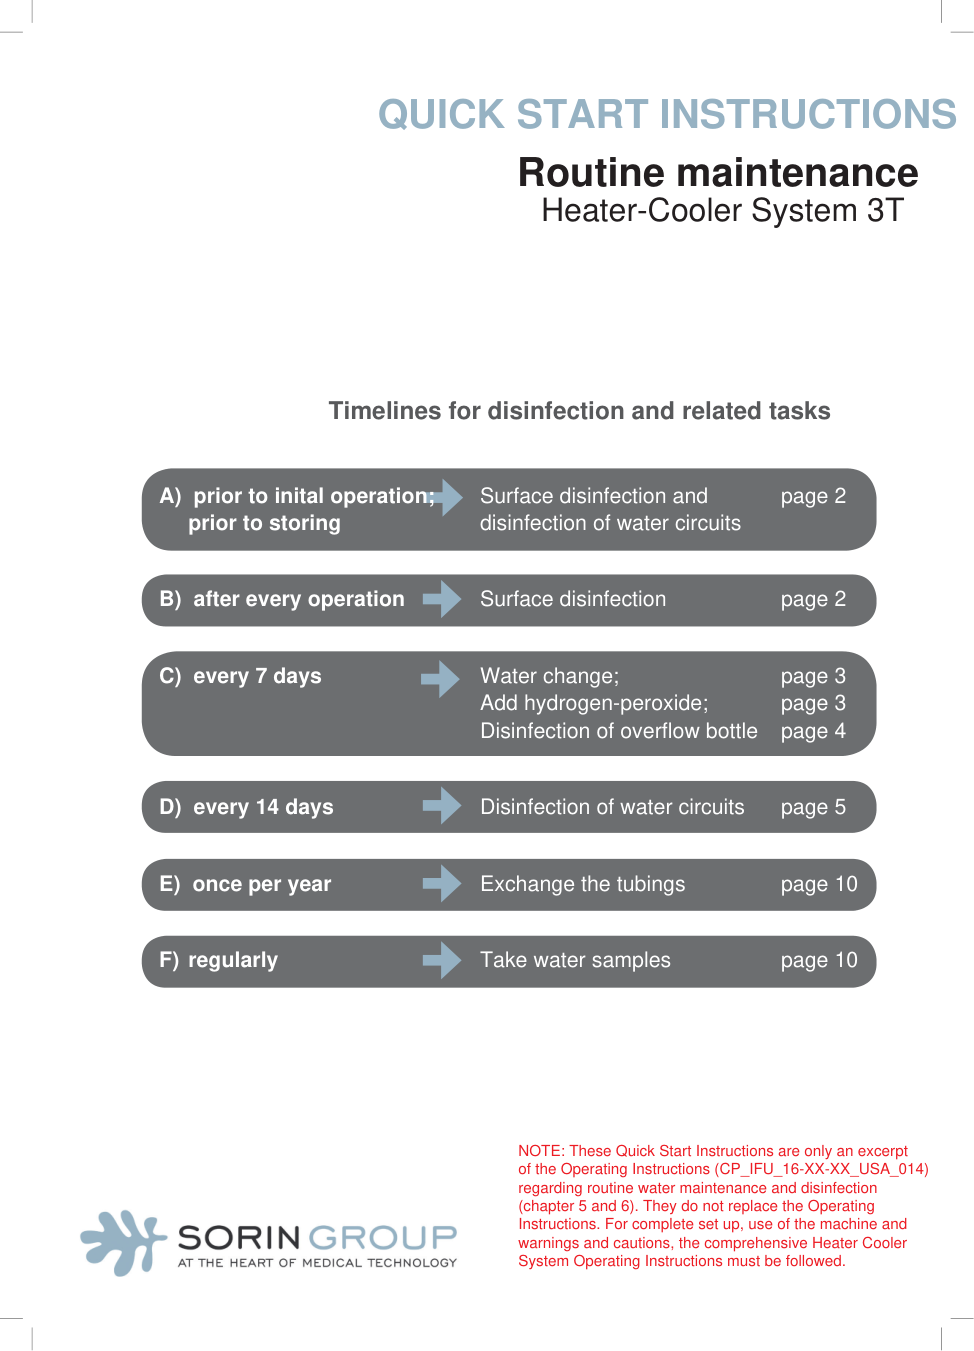

In [4]:
mostrar_pagina(OUT / 'extracted_preview.pdf', 0, titulo='Reconstrucción (control)')

## 3) `comparacion_3col.pdf` — control de la extracción **(PDF de control)**
Tres columnas: **Original | Sin texto | Reconstruido**. Confirma que el fondo quedó
limpio y que la maquetación no se perdió antes de traducir.

### Comparación de extracción (control)

`comparacion_3col.pdf` — página 1

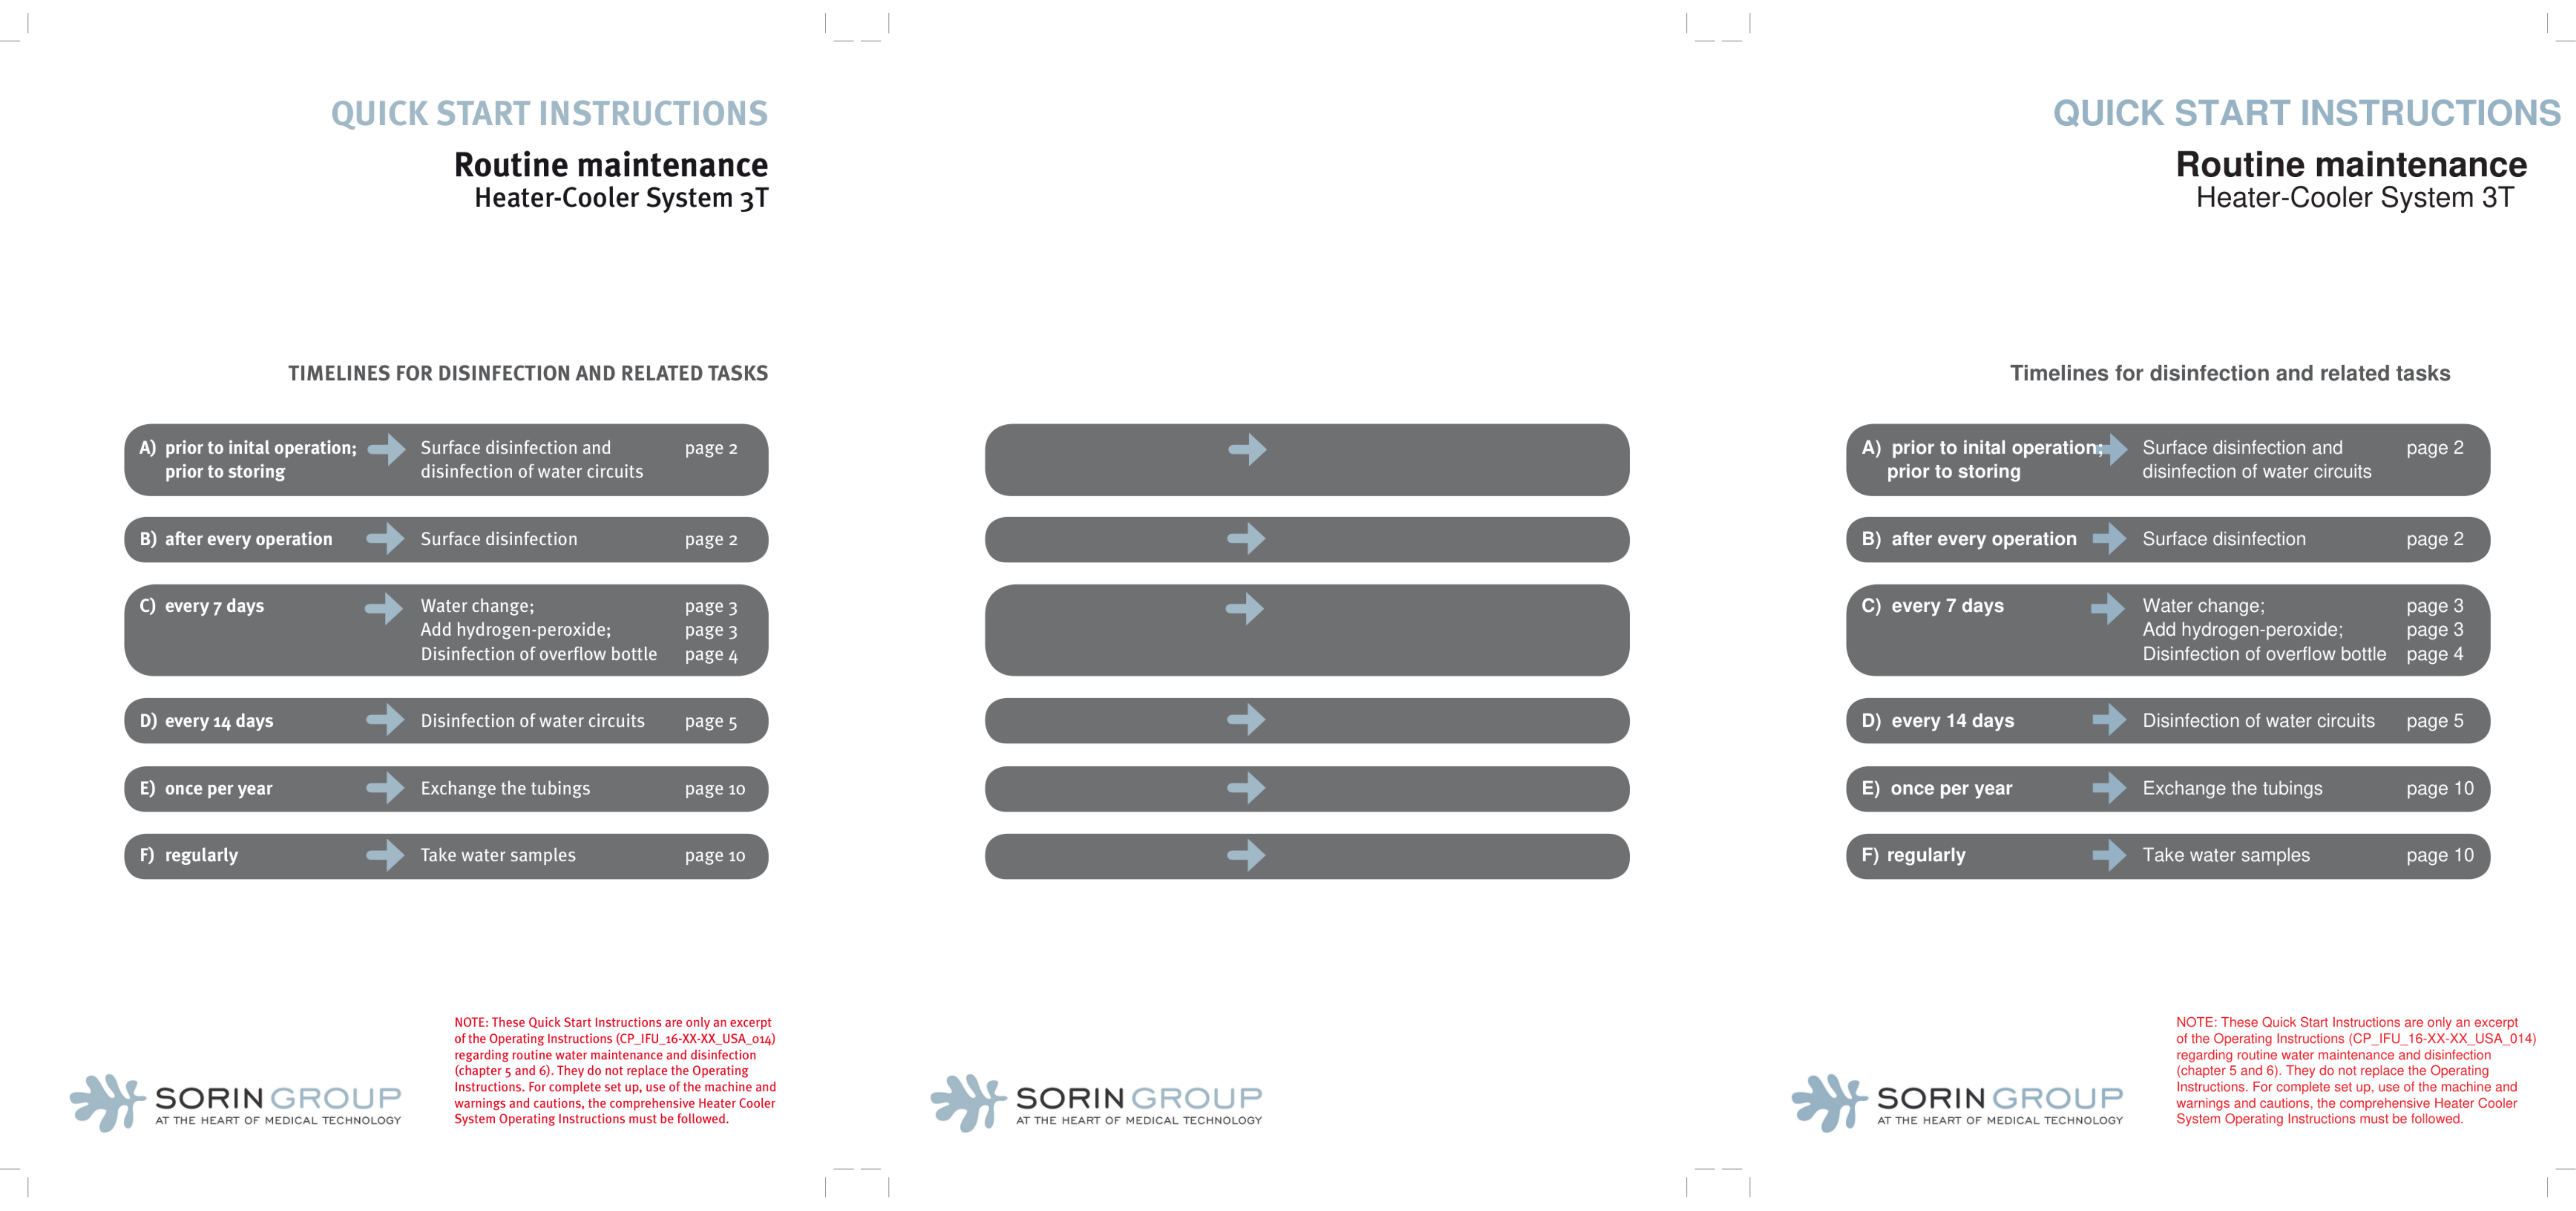

In [5]:
mostrar_pagina(OUT / 'comparacion_3col.pdf', 0, titulo='Comparación de extracción (control)')

## 4) `translated.pdf` — PDF final en español
El texto en español escrito sobre el fondo, en la posición y estilo del original.

### Traducido (final)

`translated.pdf` — página 1

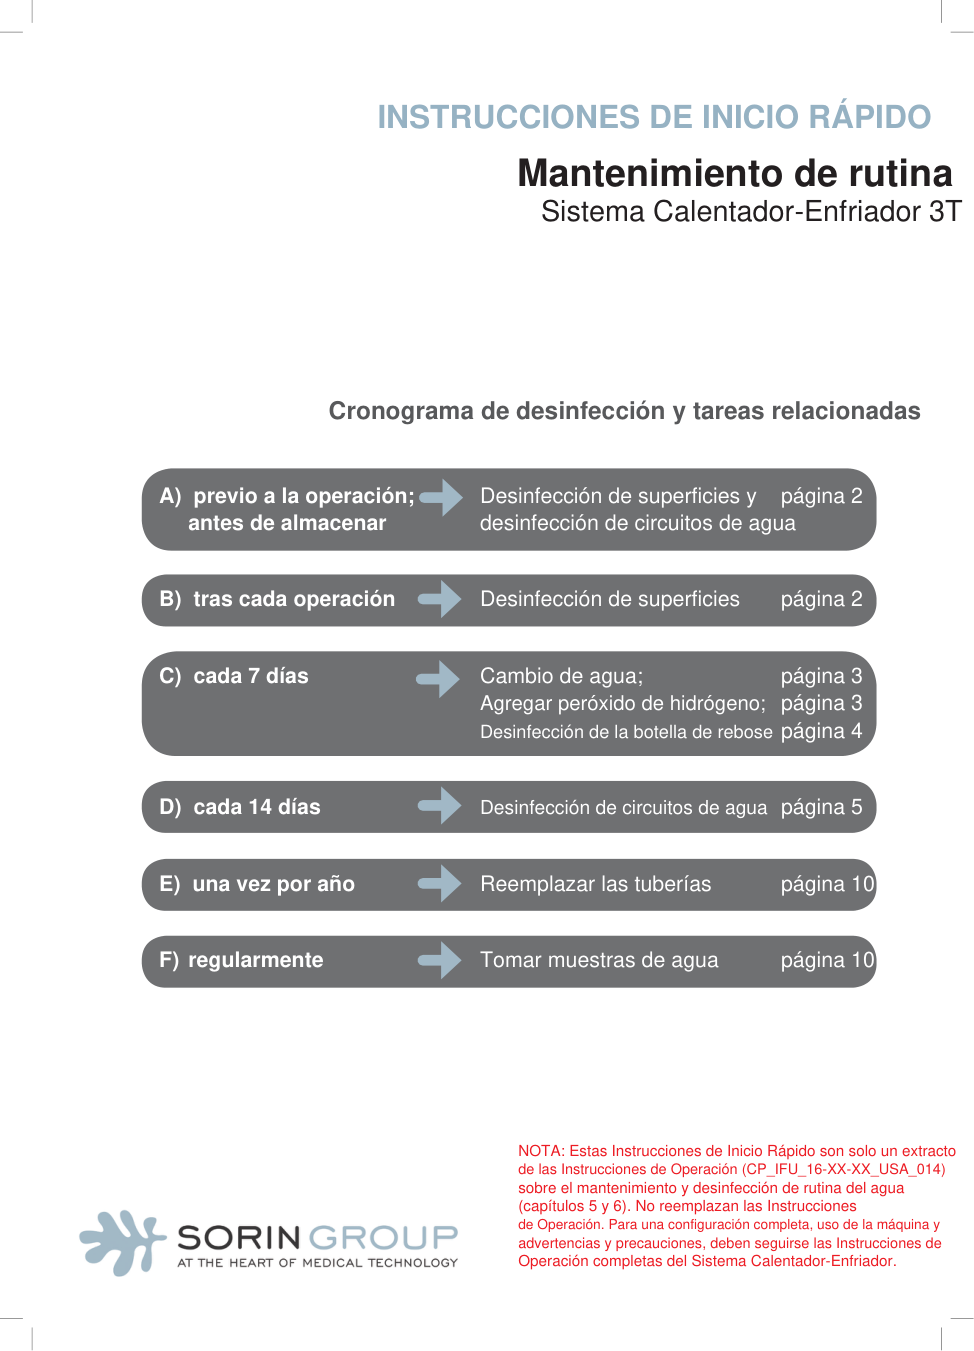

In [6]:
mostrar_pagina(OUT / 'translated.pdf', 0, titulo='Traducido (final)')

## 5) `comparacion_traducido.pdf` — control de la traducción **(PDF de control)**
Tres columnas: **Original (inglés) | Sin texto | Traducido (español)**. Verificación
final de que cada elemento gráfico permanece en su sitio y el texto en español ocupa
el lugar del inglés sin desbordes ni solapamientos.

### Comparación de traducción (control)

`comparacion_traducido.pdf` — página 1

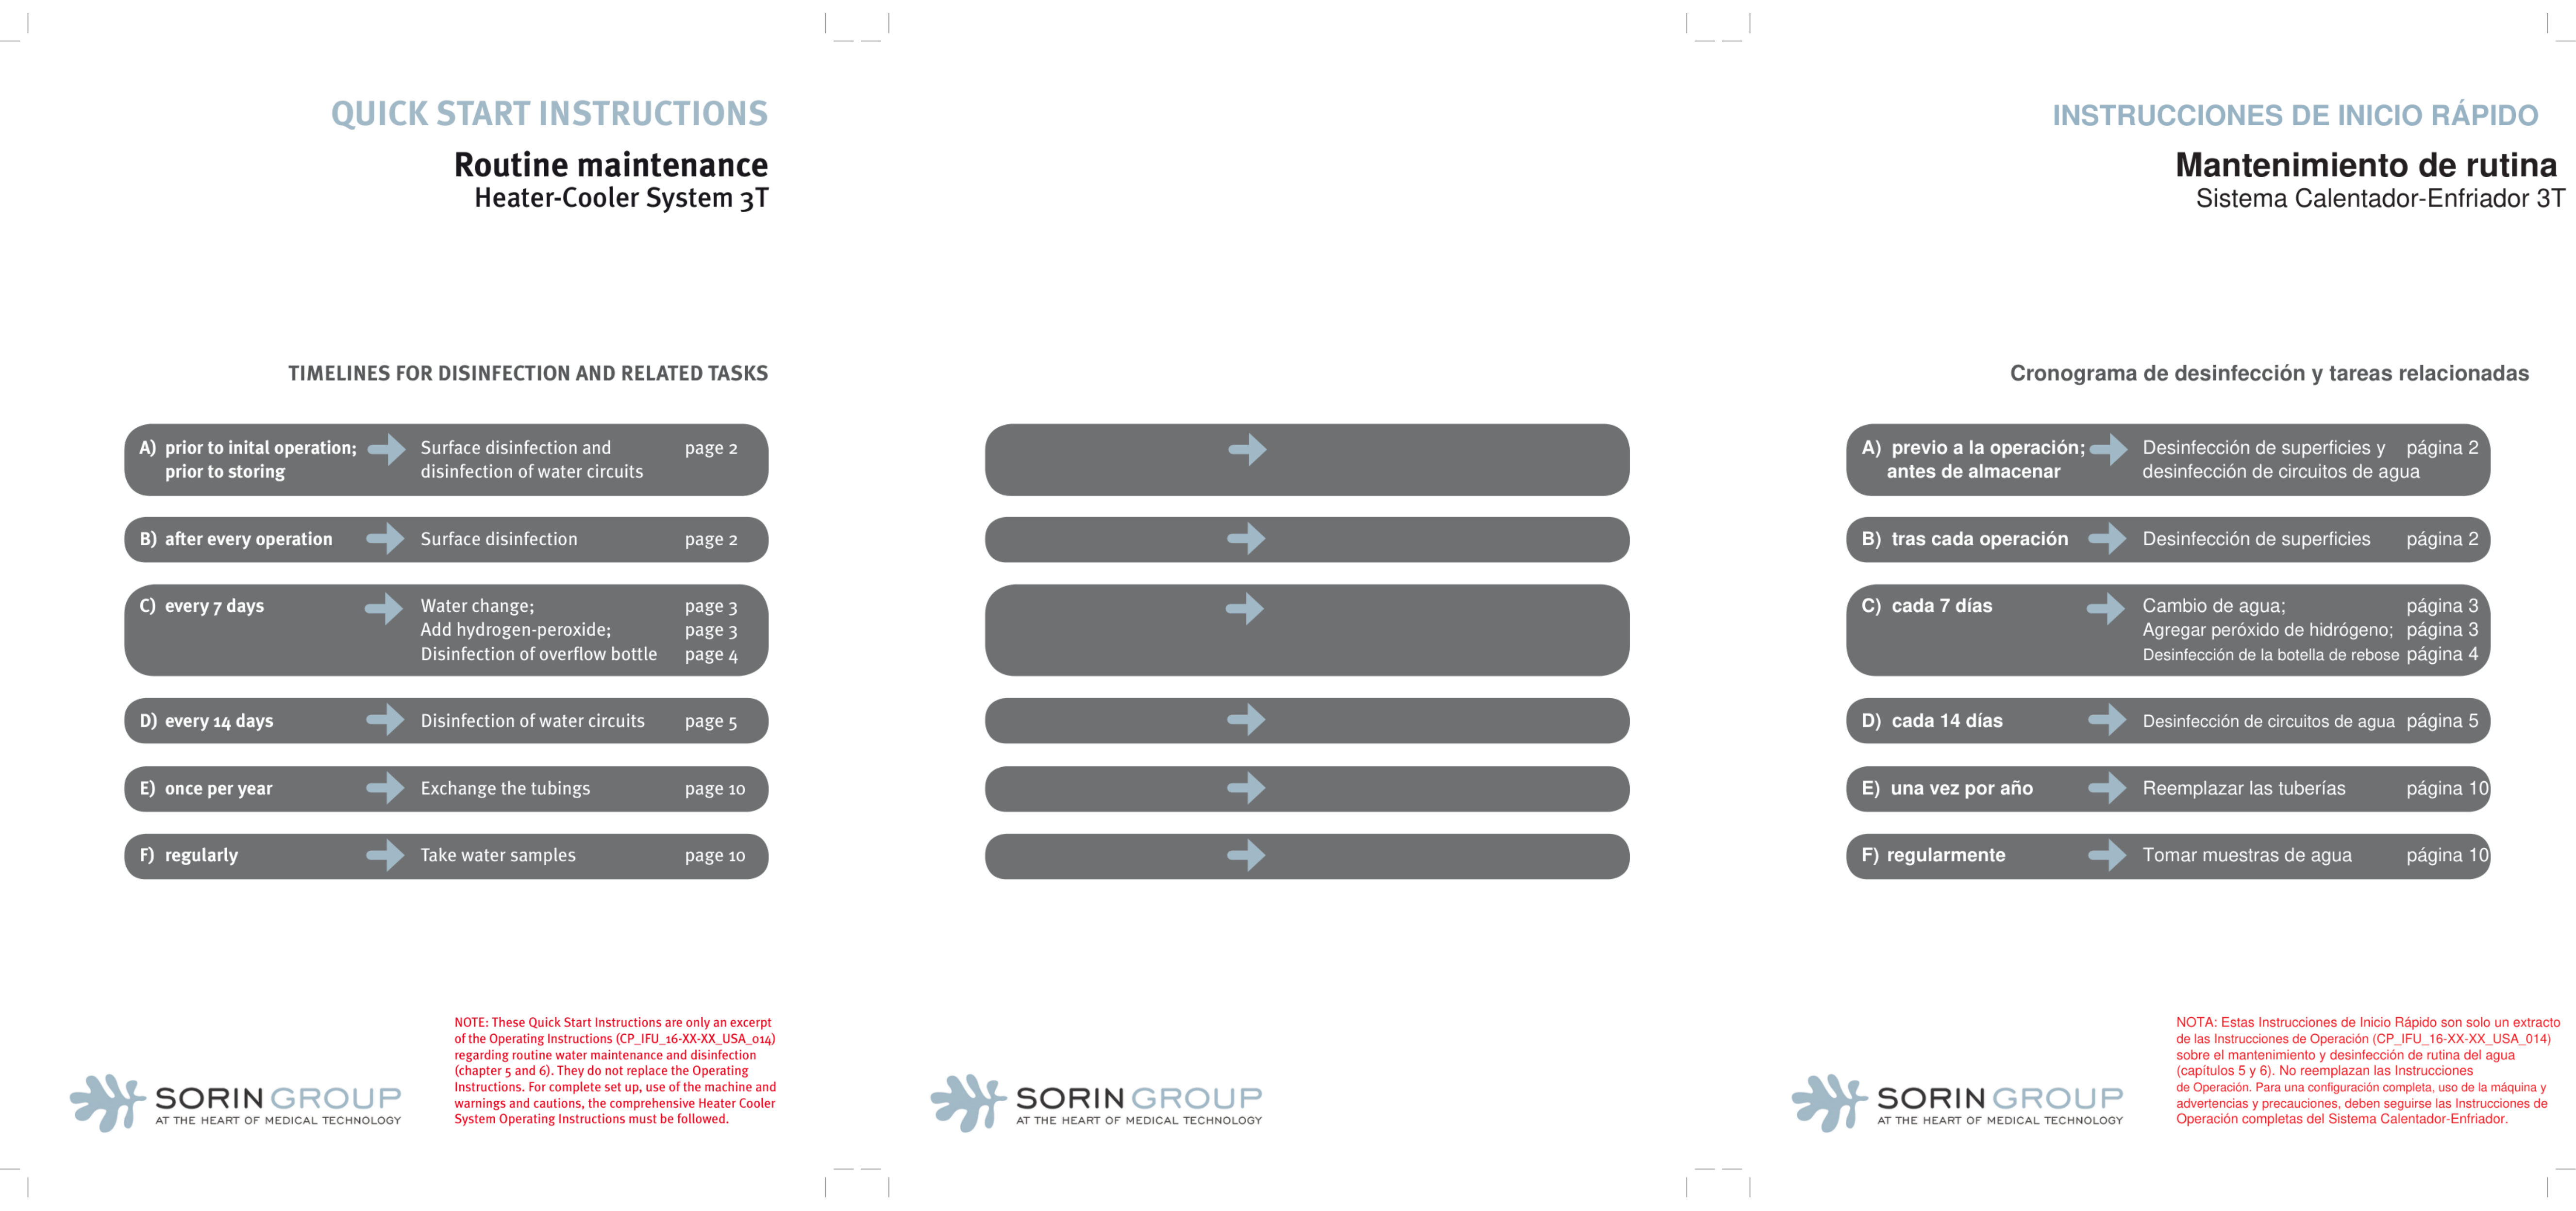

In [7]:
mostrar_pagina(OUT / 'comparacion_traducido.pdf', 0, titulo='Comparación de traducción (control)')

## Artefactos generados (`output/`)

- `extracted_text.json` / `extracted_text.txt` — texto extraído con atributos / legible
- `extracted_images.json` + `images/*.png` — imágenes extraídas con su posición
- `background_only.pdf` — original sin texto (lienzo base)
- `extracted_preview.pdf` — reconstrucción de control
- `translated.pdf` — **PDF final en español**
- `comparacion_3col.pdf` — control de la extracción
- `comparacion_traducido.pdf` — control final
